# Global XGBoost — Multi-Ticker Stock Prediction (Walk-Forward Validation)

- **Input**: 20-day sliding window of 16 features (13 technical + market proxy + relative strength + ticker_id) computed over 100 stocks — **flattened to 320-dim vector** for XGBoost.
- **Output**: Buy (1) vs Sell (0)
- **Split (Static Baseline)**: 80% train / 10% val / 10% test (chronological globally across all stocks)
- **Walk-Forward**: Expanding/Rolling window — train on N months, test on next M months, slide forward
- **Class Imbalance**: `scale_pos_weight = neg/pos` for 1-day horizon; `scale_pos_weight = 1.0` for 5-day and 10-day horizons

---

## Cell 1 · Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
import warnings
warnings.filterwarnings("ignore")

# ── Static Split Configuration ────────────────────────────────────────────────
RAW_FILE      = "data/raw_data.csv"
WINDOW_RAW    = 55    # raw window for indicator warm-up
WINDOW_KEEP   = 20    # actual timesteps fed to model
WARMUP        = WINDOW_RAW - WINDOW_KEEP   # 35 rows trimmed per ticker
BUY_THRESHOLD = 0.5

TRAIN_RATIO   = 0.80
VAL_RATIO     = 0.10
TEST_RATIO    = 0.10

# ── Walk-Forward Configuration ────────────────────────────────────────────────
# TRAIN_MONTHS  : number of months used as training window per fold
# TEST_MONTHS   : number of months used as test window per fold
# STEP_MONTHS   : how many months to slide the window forward each fold
# WF_MODE       : "expanding" keeps growing train set; "rolling" keeps fixed size
TRAIN_MONTHS  = 24   # 2 years initial training
TEST_MONTHS   = 3    # 3 months test per fold
STEP_MONTHS   = 3    # slide 3 months forward each step
WF_MODE       = "expanding"  # "expanding" or "rolling"

print(f"Global XGBoost Model (All Tickers)")
print(f"Window (raw)    : {WINDOW_RAW} days")
print(f"Window (keep)   : {WINDOW_KEEP} days")
print(f"Warm-up trim    : {WARMUP} days")
print(f"Buy threshold   : {BUY_THRESHOLD}")
print(f"Static split    : {TRAIN_RATIO:.0%} / {VAL_RATIO:.0%} / {TEST_RATIO:.0%}")
print(f"\nWalk-Forward Config:")
print(f"  Mode          : {WF_MODE}")
print(f"  Train window  : {TRAIN_MONTHS} months")
print(f"  Test window   : {TEST_MONTHS} months")
print(f"  Step size     : {STEP_MONTHS} months")

Global XGBoost Model (All Tickers)
Window (raw)    : 55 days
Window (keep)   : 20 days
Warm-up trim    : 35 days
Buy threshold   : 0.5
Static split    : 80% / 10% / 10%

Walk-Forward Config:
  Mode          : expanding
  Train window  : 24 months
  Test window   : 3 months
  Step size     : 3 months


## Cell 2 · Load OHLCV & Compute 16 Features

In [2]:
raw = pd.read_csv(RAW_FILE, parse_dates=["date"])

if "ticker_id" not in raw.columns:
    unique_tickers = raw["ticker"].unique()
    ticker_to_id = {t: i + 1 for i, t in enumerate(unique_tickers)}
    raw["ticker_id"] = raw["ticker"].map(ticker_to_id)

raw = raw.sort_values(["ticker", "date"]).reset_index(drop=True)
raw["temp_ret_1d"] = raw.groupby("ticker")["close"].pct_change(1)

market_proxy = raw.groupby("date")["temp_ret_1d"].mean().reset_index()
market_proxy.rename(columns={"temp_ret_1d": "market_ret_1d"}, inplace=True)
raw = pd.merge(raw, market_proxy, on="date", how="left")


def compute_rsi(series, window=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = (-delta.clip(upper=0))
    avg_gain = gain.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    rs       = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


def compute_atr(high, low, close, window=14):
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()


def compute_obv(close, volume):
    sign = np.sign(close.diff()).fillna(0)
    return (sign * volume).cumsum()


def process_ticker(df):
    c, o, h, lo, v = df["close"], df["open"], df["high"], df["low"], df["volume"].astype(float)
    hl = h - lo

    df["hl_range"]       = hl / c
    df["body_ratio"]     = (c - o).abs() / hl.replace(0, np.nan)
    df["close_position"] = (c - lo) / hl.replace(0, np.nan)
    df["return_1d"]      = c.pct_change(1)

    obv       = compute_obv(c, v)
    obv_lag5  = obv.shift(5)
    df["obv_change"]     = (obv - obv_lag5) / obv_lag5.abs().replace(0, np.nan)
    df["return_5d"]      = c.pct_change(5)
    df["rsi"]            = compute_rsi(c, window=14)
    df["atr_ratio"]      = compute_atr(h, lo, c, window=14) / c

    ema3  = c.ewm(span=3,  adjust=False).mean()
    ema10 = c.ewm(span=10, adjust=False).mean()
    df["ema_ratio"]      = ema3 / ema10 - 1

    bb_mid   = c.rolling(10).mean()
    bb_std   = c.rolling(10).std(ddof=0)
    bb_upper = bb_mid + 2 * bb_std
    bb_lower = bb_mid - 2 * bb_std
    df["bb_pctb"]        = (c - bb_lower) / (bb_upper - bb_lower).replace(0, np.nan)

    vol_ma10 = v.rolling(10).mean()
    df["volume_ratio"]   = v / vol_ma10.replace(0, np.nan)

    ret   = c.pct_change(1)
    std4  = ret.rolling(4).std()
    std10 = ret.rolling(10).std()
    df["vol_trend"]      = std4 / std10.replace(0, np.nan)

    macd_line = c.ewm(span=5,  adjust=False).mean() - c.ewm(span=10, adjust=False).mean()
    signal    = macd_line.ewm(span=5, adjust=False).mean()
    df["macd_hist"]      = macd_line - signal

    df["relative_strength"] = df["return_1d"] - df["market_ret_1d"]

    # 1-day label: price tomorrow > price today
    df["label"] = (df["close"].shift(-1) > df["close"]).astype(int)

    return df.iloc[WARMUP:-1].reset_index(drop=True)


processed_frames = []
for ticker, grp in raw.groupby("ticker"):
    res = process_ticker(grp.copy())
    processed_frames.append(res)

global_df = pd.concat(processed_frames, ignore_index=True)

FEATURE_COLS = [
    "ticker_id",
    "hl_range", "body_ratio", "close_position",
    "return_1d", "obv_change", "return_5d",
    "rsi", "atr_ratio", "ema_ratio",
    "bb_pctb", "volume_ratio", "vol_trend", "macd_hist",
    "market_ret_1d", "relative_strength"
]

global_df = global_df.replace([np.inf, -np.inf], np.nan)
global_df = global_df.dropna(subset=FEATURE_COLS + ["label"]).reset_index(drop=True)

# Outlier clipping
for col in FEATURE_COLS:
    if col == "ticker_id":
        continue
    p01 = global_df[col].quantile(0.01)
    p99 = global_df[col].quantile(0.99)
    global_df[col] = global_df[col].clip(lower=p01, upper=p99)

print(f"Total rows after processing: {len(global_df):,}")
print(f"Features : {len(FEATURE_COLS)}")
print(f"Label    : {global_df['label'].value_counts().sort_index().to_dict()}")
print(f"Date range: {global_df['date'].min().date()} → {global_df['date'].max().date()}")

Total rows after processing: 339,156
Features : 16
Label    : {0: 193639, 1: 145517}
Date range: 2003-05-20 → 2026-04-10


## Cell 3 · Create Sliding Windows & Global Chronological Split (Static Baseline)

Sliding window logic mirrors the LSTM notebook exactly:
- Each sample = 20-day window of shape `(20, 16)` → **flattened to `(320,)`** for XGBoost (tree models require 2D input)
- All samples across all tickers are sorted chronologically before the global 80/10/10 split

In [3]:
W = WINDOW_KEEP  # 20

X_list       = []
y_list       = []
dates        = []
tickers_list = []

for ticker, grp in global_df.groupby("ticker"):
    grp = grp.reset_index(drop=True)
    for i in range(W - 1, len(grp)):
        window = grp[FEATURE_COLS].iloc[i - W + 1 : i + 1].values  # (20, 16)
        X_list.append(window.flatten())                              # (320,) — flattened for XGBoost
        y_list.append(int(grp["label"].iloc[i]))
        dates.append(grp["date"].iloc[i])
        tickers_list.append(ticker)

X       = np.array(X_list, dtype=np.float32)   # (N, 320)
y       = np.array(y_list, dtype=np.float32)    # (N,)
dates   = np.array(dates)
tickers = np.array(tickers_list)

# Sort all samples chronologically — global time cut-off (same as LSTM)
sort_idx = np.argsort(dates)
X        = X[sort_idx]
y        = y[sort_idx]
dates    = dates[sort_idx]
tickers  = tickers[sort_idx]

n         = len(X)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

X_train, y_train = X[:train_end],        y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]
d_train          = dates[:train_end]
d_val            = dates[train_end:val_end]
d_test           = dates[val_end:]
t_test           = tickers[val_end:]

print(f"Input shape  : {X.shape}  (samples, features=16_cols×{W}_days)")
print()
print(f"{'Set':<8} {'Rows':>7}  {'Date Range':<32}  {'Down':>6}  {'Up':>6}  {'Up%':>6}")
print("-" * 75)
for name, xs, ys, ds in [
    ("Train", X_train, y_train, d_train),
    ("Val",   X_val,   y_val,   d_val),
    ("Test",  X_test,  y_test,  d_test),
]:
    n0  = int((ys == 0).sum())
    n1  = int((ys == 1).sum())
    pct = n1 / len(ys) * 100
    d0  = pd.Timestamp(ds.min()).strftime('%Y-%m-%d')
    d1  = pd.Timestamp(ds.max()).strftime('%Y-%m-%d')
    print(f"{name:<8} {len(xs):>7,}  {d0} → {d1:<19}  {n0:>6,}  {n1:>6,}  {pct:>5.1f}%")

Input shape  : (337275, 320)  (samples, features=16_cols×20_days)

Set         Rows  Date Range                          Down      Up     Up%
---------------------------------------------------------------------------
Train    269,820  2003-07-09 → 2023-06-19           155,700  114,120   42.3%
Val       33,727  2023-06-19 → 2024-11-06           18,161  15,566   46.2%
Test      33,728  2024-11-06 → 2026-04-10           18,671  15,057   44.6%


## Cell 4 · Train XGBoost 1-Day Horizon (Static Baseline)

Class imbalance handled via XGBoost's native `scale_pos_weight = neg / pos`.

In [6]:
# XGBoost native class imbalance handling for 1-day horizon
""" scale_pos_weight_1d = float((y_train == 0).sum() / (y_train == 1).sum()"""
scale_pos_weight_1d = sum(y_train == 0) / sum(y_train == 1)

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight_1d,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.5,
    colsample_bytree=0.5,
    min_child_weight=30,
    gamma=1.0,
    reg_lambda=1.0,
    reg_alpha=0.5,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"Static XGBoost (1-day) trained!")
print(f"  scale_pos_weight : {scale_pos_weight_1d:.4f}")
print(f"  Trees            : {xgb_model.n_estimators}")
print(f"  Max depth        : {xgb_model.max_depth}")
print(f"  Learning rate    : {xgb_model.learning_rate}")
print(f"  Feature vector   : {X_train.shape[1]}  ({len(FEATURE_COLS)} features × {W} days)")
print(f"  Train rows       : {len(X_train):,}")

prob_train = xgb_model.predict_proba(X_train)[:, 1]
prob_val   = xgb_model.predict_proba(X_val)[:, 1]
prob_test  = xgb_model.predict_proba(X_test)[:, 1]

pred_train = (prob_train >= BUY_THRESHOLD).astype(int)
pred_val   = (prob_val   >= BUY_THRESHOLD).astype(int)
pred_test  = (prob_test  >= BUY_THRESHOLD).astype(int)

Static XGBoost (1-day) trained!
  scale_pos_weight : 1.3644
  Trees            : 200
  Max depth        : 4
  Learning rate    : 0.05
  Feature vector   : 320  (16 features × 20 days)
  Train rows       : 269,820


## Cell 5 · Evaluation (Static Baseline)

In [7]:
def evaluate(y_true, y_pred, y_prob, set_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = float("nan")

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    print(f"\n{'='*60}")
    print(f"  {set_name}  (threshold = {BUY_THRESHOLD})")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"                  Predicted")
    print(f"               Sell     Buy")
    print(f"  Actual Sell  {cm[0,0]:>5,}   {cm[0,1]:>5,}")
    print(f"  Actual Buy   {cm[1,0]:>5,}   {cm[1,1]:>5,}")

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc}


m_train = evaluate(y_train, pred_train, prob_train, "TRAIN SET")
m_val   = evaluate(y_val,   pred_val,   prob_val,   "VALIDATION SET")
m_test  = evaluate(y_test,  pred_test,  prob_test,  "TEST SET")

print(f"\n{'='*60}\n  STATIC SPLIT SUMMARY (1-day)\n{'='*60}")
summary_df = pd.DataFrame({"Train": m_train, "Val": m_val, "Test": m_test}).T
print(summary_df.round(4).to_string())

gap = m_train["f1"] - m_test["f1"]
print(f"\n  Train-Test F1 gap: {gap:.4f}")


  TRAIN SET  (threshold = 0.5)
  Accuracy  : 0.6174
  Precision : 0.5422
  Recall    : 0.6136
  F1-score  : 0.5757
  AUC-ROC   : 0.6664

  Confusion Matrix:
                  Predicted
               Sell     Buy
  Actual Sell  96,564   59,136
  Actual Buy   44,092   70,028

  VALIDATION SET  (threshold = 0.5)
  Accuracy  : 0.5325
  Precision : 0.4949
  Recall    : 0.6307
  F1-score  : 0.5546
  AUC-ROC   : 0.5564

  Confusion Matrix:
                  Predicted
               Sell     Buy
  Actual Sell  8,142   10,019
  Actual Buy   5,749   9,817

  TEST SET  (threshold = 0.5)
  Accuracy  : 0.5427
  Precision : 0.4902
  Recall    : 0.6104
  F1-score  : 0.5438
  AUC-ROC   : 0.5698

  Confusion Matrix:
                  Predicted
               Sell     Buy
  Actual Sell  9,114   9,557
  Actual Buy   5,866   9,191

  STATIC SPLIT SUMMARY (1-day)
       accuracy  precision  recall      f1     auc
Train    0.6174     0.5422  0.6136  0.5757  0.6664
Val      0.5325     0.4949  0.6307  0.554

## Cell 6 · Walk-Forward Validation

- **Expanding mode**: train from start to month T, test on months T+1 → T+M, then grow training window by M months and repeat.
- **Rolling mode**: keep a fixed training window size, slide both start and end forward.

Goal: assess model stability across different market regimes.

In [8]:
def build_walk_forward_folds(dates_arr, train_months, test_months, step_months, mode="expanding"):
    dates_pd     = pd.to_datetime(dates_arr).tz_localize(None)
    global_start = dates_pd.min()
    global_end   = dates_pd.max()

    folds       = []
    fold_num    = 1
    train_start = global_start
    train_end   = global_start + pd.DateOffset(months=train_months)

    while True:
        test_start = train_end
        test_end   = train_end + pd.DateOffset(months=test_months)

        if test_start >= global_end:
            break

        test_end = min(test_end, global_end + pd.Timedelta(days=1))

        train_mask = (dates_pd >= train_start) & (dates_pd < train_end)
        test_mask  = (dates_pd >= test_start)  & (dates_pd < test_end)

        train_idx = np.where(train_mask)[0]
        test_idx  = np.where(test_mask)[0]

        if len(train_idx) < 100 or len(test_idx) < 10:
            if mode == "expanding":
                train_end = train_end + pd.DateOffset(months=step_months)
            else:
                train_start = train_start + pd.DateOffset(months=step_months)
                train_end   = train_end   + pd.DateOffset(months=step_months)
            continue

        folds.append({
            "fold"        : fold_num,
            "train_start" : train_start.date(),
            "train_end"   : (train_end - pd.Timedelta(days=1)).date(),
            "test_start"  : test_start.date(),
            "test_end"    : (test_end  - pd.Timedelta(days=1)).date(),
            "train_idx"   : train_idx,
            "test_idx"    : test_idx,
        })
        fold_num += 1

        if mode == "expanding":
            train_end = train_end + pd.DateOffset(months=step_months)
        else:
            train_start = train_start + pd.DateOffset(months=step_months)
            train_end   = train_end   + pd.DateOffset(months=step_months)

    return folds


def run_walk_forward(
    X_all, y_all, dates_all,
    train_months, test_months, step_months,
    mode="expanding", threshold=0.5,
    scale_pos_weight_override=None,
):
    """
    Execute walk-forward validation and collect per-fold metrics.

    scale_pos_weight_override: if None, compute neg/pos per fold.
                               If a float (e.g. 1.0), use that fixed value for all folds.
    """
    folds = build_walk_forward_folds(
        dates_all, train_months, test_months, step_months, mode
    )

    print(f"Walk-Forward mode : {mode}")
    print(f"Total folds found : {len(folds)}")
    print(f"{'Fold':<5} {'Train Period':<24} {'Test Period':<24} {'#Train':>7} {'#Test':>6}")
    print("-" * 75)
    for f in folds:
        print(f"{f['fold']:<5} "
              f"{str(f['train_start'])+' → '+str(f['train_end']):<24} "
              f"{str(f['test_start'])+' → '+str(f['test_end']):<24} "
              f"{len(f['train_idx']):>7,} {len(f['test_idx']):>6,}")

    results = []

    for f in folds:
        X_tr, y_tr = X_all[f["train_idx"]], y_all[f["train_idx"]]
        X_te, y_te = X_all[f["test_idx"]],  y_all[f["test_idx"]]

        if scale_pos_weight_override is not None:
            sw = scale_pos_weight_override
        else:
            pos = max(int((y_tr == 1).sum()), 1)
            neg = int((y_tr == 0).sum())
            sw  = neg / pos

        model = XGBClassifier(
            scale_pos_weight=sw,
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.5,
            colsample_bytree=0.5,
            min_child_weight=30,
            gamma=1.0,
            reg_lambda=1.0,
            reg_alpha=0.5,
            random_state=42,
            n_jobs=-1,
        )
        model.fit(X_tr, y_tr)

        prob_te = model.predict_proba(X_te)[:, 1]
        pred_te = (prob_te >= threshold).astype(int)

        acc  = accuracy_score(y_te, pred_te)
        prec = precision_score(y_te, pred_te, zero_division=0)
        rec  = recall_score(y_te, pred_te, zero_division=0)
        f1   = f1_score(y_te, pred_te, zero_division=0)
        try:
            auc = roc_auc_score(y_te, prob_te)
        except Exception:
            auc = float("nan")

        results.append({
            "fold"        : f["fold"],
            "train_start" : f["train_start"],
            "train_end"   : f["train_end"],
            "test_start"  : f["test_start"],
            "test_end"    : f["test_end"],
            "n_train"     : len(y_tr),
            "n_test"      : len(y_te),
            "accuracy"    : acc,
            "precision"   : prec,
            "recall"      : rec,
            "f1"          : f1,
            "auc"         : auc,
        })

        print(f"  Fold {f['fold']:>2} | Test {f['test_start']} → {f['test_end']} "
              f"| F1={f1:.4f}  AUC={auc:.4f}  Acc={acc:.4f}")

    return pd.DataFrame(results)


# Run walk-forward for the 1-day horizon
# scale_pos_weight computed per fold from actual class ratio
print("Starting Walk-Forward Validation (1-day)...\n")
wf_results = run_walk_forward(
    X, y, dates,
    train_months=TRAIN_MONTHS,
    test_months=TEST_MONTHS,
    step_months=STEP_MONTHS,
    mode=WF_MODE,
    threshold=BUY_THRESHOLD,
    scale_pos_weight_override=None,  # compute neg/pos per fold
)

Starting Walk-Forward Validation (1-day)...

Walk-Forward mode : expanding
Total folds found : 82
Fold  Train Period             Test Period               #Train  #Test
---------------------------------------------------------------------------
1     2003-07-09 → 2006-01-08  2006-01-09 → 2006-04-08      250    149
2     2003-07-09 → 2006-04-08  2006-04-09 → 2006-07-08      399    302
3     2003-07-09 → 2006-07-08  2006-07-09 → 2006-10-08      701    361
4     2003-07-09 → 2006-10-08  2006-10-09 → 2007-01-08    1,062    432
5     2003-07-09 → 2007-01-08  2007-01-09 → 2007-04-08    1,494    447
6     2003-07-09 → 2007-04-08  2007-04-09 → 2007-07-08    1,941    875
7     2003-07-09 → 2007-07-08  2007-07-09 → 2007-10-08    2,816  1,138
8     2003-07-09 → 2007-10-08  2007-10-09 → 2008-01-08    3,954  1,249
9     2003-07-09 → 2008-01-08  2008-01-09 → 2008-04-08    5,203  1,151
10    2003-07-09 → 2008-04-08  2008-04-09 → 2008-07-08    6,354    720
11    2003-07-09 → 2008-07-08  2008-07-09 → 2

## Cell 7 · Walk-Forward Results Summary & Stability Analysis

In [9]:
metric_cols = ["accuracy", "precision", "recall", "f1", "auc"]

print(f"{'='*75}")
print(f"  WALK-FORWARD VALIDATION SUMMARY  (mode={WF_MODE}, horizon=1d)")
print(f"{'='*75}")

if wf_results.empty:
    print("0 folds found — check TRAIN_MONTHS settings or input data.")
else:
    display_cols = ["fold", "test_start", "test_end", "n_train", "n_test",
                    "accuracy", "precision", "recall", "f1", "auc"]
    print("\nPer-Fold Results:")
    print(wf_results[display_cols].round(4).to_string(index=False))

    print(f"\n{'─'*75}")
    print("Aggregate Statistics Across All Folds:")
    print(f"{'─'*75}")
    agg = wf_results[metric_cols].agg(["mean", "std", "min", "max"])
    print(agg.round(4).to_string())

    print(f"\n{'─'*75}")
    print("Stability (Coefficient of Variation = std / mean, lower is better):")
    print(f"{'─'*75}")
    cv = (wf_results[metric_cols].std() / wf_results[metric_cols].mean()).round(4)
    for metric, val in cv.items():
        stability = "STABLE" if val < 0.10 else ("MODERATE" if val < 0.20 else "UNSTABLE")
        print(f"  {metric:<12} CV={val:.4f}  → {stability}")

    print(f"\n{'─'*75}")
    print("Walk-Forward Mean vs Static Single-Split Test:")
    print(f"{'─'*75}")
    wf_mean    = wf_results[metric_cols].mean()
    comparison = pd.DataFrame({
        "WF_Mean"    : wf_mean,
        "Static_Test": pd.Series(m_test),
        "Delta"      : wf_mean - pd.Series(m_test),
    })
    print(comparison.round(4).to_string())

  WALK-FORWARD VALIDATION SUMMARY  (mode=expanding, horizon=1d)

Per-Fold Results:
 fold test_start   test_end  n_train  n_test  accuracy  precision  recall     f1    auc
    1 2006-01-09 2006-04-08      250     149    0.5705     0.5705  1.0000 0.7265 0.5000
    2 2006-04-09 2006-07-08      399     302    0.5927     0.4453  0.5229 0.4810 0.5761
    3 2006-07-09 2006-10-08      701     361    0.5263     0.4497  0.4295 0.4393 0.4936
    4 2006-10-09 2007-01-08     1062     432    0.5694     0.5633  0.6000 0.5811 0.5964
    5 2007-01-09 2007-04-08     1494     447    0.5660     0.4960  0.6458 0.5611 0.6055
    6 2007-04-09 2007-07-08     1941     875    0.6286     0.4871  0.4763 0.4817 0.6151
    7 2007-07-09 2007-10-08     2816    1138    0.5650     0.4513  0.4523 0.4518 0.5604
    8 2007-10-09 2008-01-08     3954    1249    0.6125     0.3641  0.3622 0.3632 0.5588
    9 2008-01-09 2008-04-08     5203    1151    0.4083     0.3053  0.6550 0.4165 0.5012
   10 2008-04-09 2008-07-08     6354 

## Cell 8 · Walk-Forward Metric Trend Chart

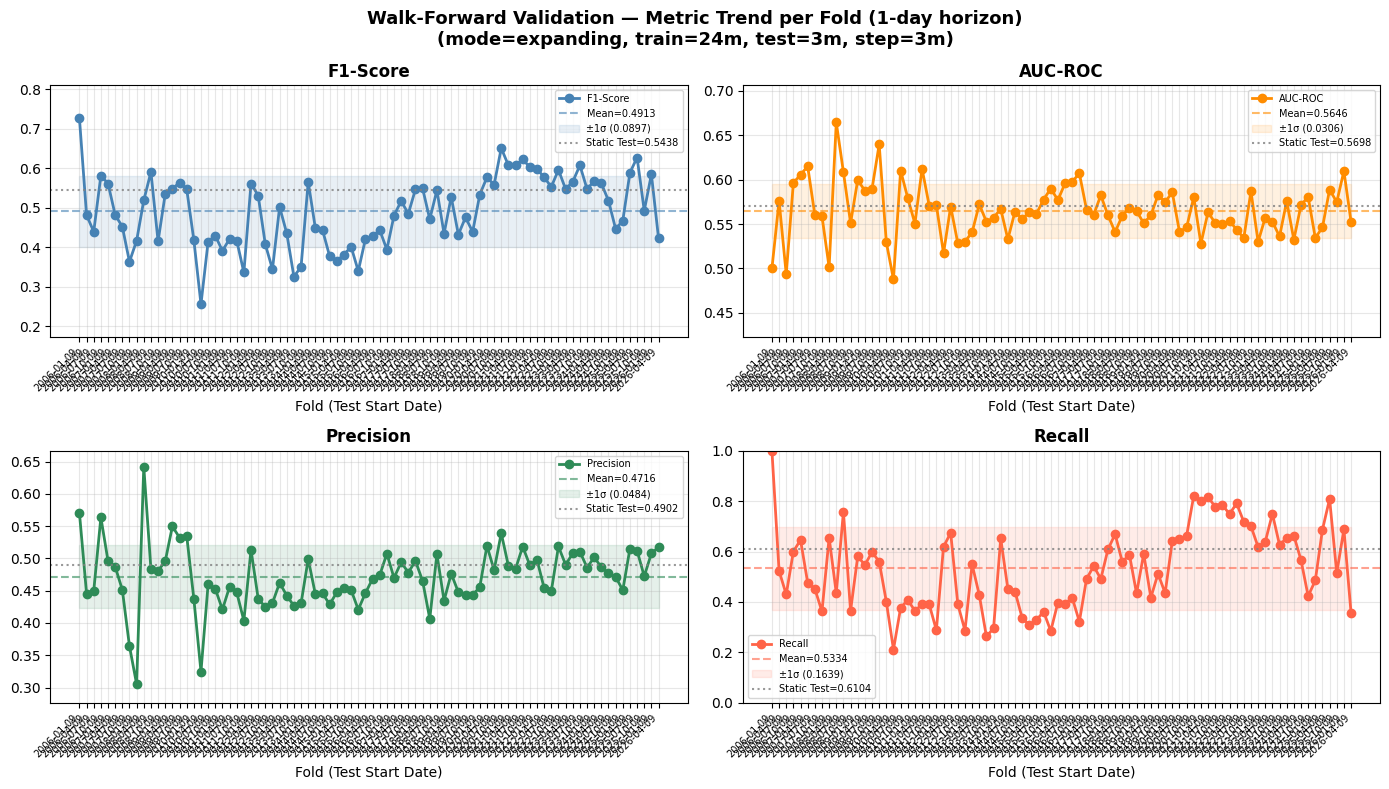

Chart saved as walk_forward_metric_trend.png


In [10]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(
        f"Walk-Forward Validation — Metric Trend per Fold (1-day horizon)\n"
        f"(mode={WF_MODE}, train={TRAIN_MONTHS}m, test={TEST_MONTHS}m, step={STEP_MONTHS}m)",
        fontsize=13, fontweight="bold"
    )

    fold_labels  = [str(row["test_start"]) for _, row in wf_results.iterrows()]
    plot_metrics = [
        ("f1",        "F1-Score",  "steelblue"),
        ("auc",       "AUC-ROC",   "darkorange"),
        ("precision", "Precision", "seagreen"),
        ("recall",    "Recall",    "tomato"),
    ]

    for ax, (col, title, color) in zip(axes.flatten(), plot_metrics):
        vals     = wf_results[col].values
        mean_val = np.nanmean(vals)
        std_val  = np.nanstd(vals)

        ax.plot(range(len(vals)), vals, marker="o", color=color, linewidth=2, label=title)
        ax.axhline(mean_val, color=color, linestyle="--", alpha=0.6, label=f"Mean={mean_val:.4f}")
        ax.fill_between(
            range(len(vals)),
            mean_val - std_val, mean_val + std_val,
            alpha=0.12, color=color, label=f"±1σ ({std_val:.4f})"
        )
        ax.axhline(m_test[col], color="gray", linestyle=":", alpha=0.8,
                   label=f"Static Test={m_test[col]:.4f}")

        ax.set_title(title, fontweight="bold")
        ax.set_xticks(range(len(fold_labels)))
        ax.set_xticklabels(fold_labels, rotation=45, ha="right", fontsize=7)
        ax.set_xlabel("Fold (Test Start Date)")
        ax.set_ylim(
            max(0, mean_val - 3 * std_val - 0.05),
            min(1, mean_val + 3 * std_val + 0.05)
        )
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("walk_forward_metric_trend.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Chart saved as walk_forward_metric_trend.png")

except ImportError:
    print("matplotlib not available — skipping chart.")

## Cell 9 · Feature Importance (Final Static 1-Day Model)

In [11]:
# Build column names: feature_dXX for each day in the 20-day window
col_names = []
for feat in FEATURE_COLS:
    for d in range(1, WINDOW_KEEP + 1):
        col_names.append(f"{feat}_d{d:02d}")

importances = pd.Series(xgb_model.feature_importances_, index=col_names)
top20       = importances.sort_values(ascending=False).head(20)

print("Top 20 most important features:\n")
for rank, (name, imp) in enumerate(top20.items(), 1):
    bar = '█' * int(imp / top20.max() * 30)
    print(f"{rank:<6} {name:<25} {imp:>10.4f}  {bar}")

print("\n\nImportance aggregated by feature type:\n")
feat_agg = {}
for feat in FEATURE_COLS:
    mask = [c for c in col_names if c.startswith(feat + "_d")]
    feat_agg[feat] = importances[mask].sum()

feat_agg = pd.Series(feat_agg).sort_values(ascending=False)
for name, imp in feat_agg.items():
    bar = '█' * int(imp / feat_agg.max() * 30)
    print(f"{name:<20} {imp:>16.4f}  {bar}")

Top 20 most important features:

1      relative_strength_d18         0.0171  ██████████████████████████████
2      vol_trend_d10                 0.0171  █████████████████████████████
3      relative_strength_d13         0.0171  █████████████████████████████
4      relative_strength_d02         0.0150  ██████████████████████████
5      relative_strength_d09         0.0111  ███████████████████
6      macd_hist_d06                 0.0102  █████████████████
7      atr_ratio_d09                 0.0094  ████████████████
8      market_ret_1d_d12             0.0078  █████████████
9      relative_strength_d03         0.0077  █████████████
10     relative_strength_d16         0.0075  █████████████
11     relative_strength_d08         0.0075  █████████████
12     relative_strength_d19         0.0073  ████████████
13     volume_ratio_d14              0.0072  ████████████
14     macd_hist_d04                 0.0071  ████████████
15     return_1d_d08                 0.0070  ████████████
16     macd

## Cell 10 · Multi-Horizon Training (5-Day & 10-Day)

Label creation pattern mirrors LSTM notebook exactly:
- Call `process_ticker()` (which creates the default 1-day label)
- **Override** label with `close.shift(-horizon) > close` for the target horizon

Class imbalance: `scale_pos_weight = 1.0` for both 5-day and 10-day horizons
(longer-horizon labels tend to be more balanced; mirrors LSTM `pos_weight=1.0`).

In [12]:
def train_and_evaluate_horizon(horizon: int, threshold: float = 0.5):
    print(f"\n{'='*60}\n  HORIZON: {horizon} DAYS\n{'='*60}")

    # ── Rebuild features, then override label for this horizon ────────────────
    frames = []
    for ticker, grp in raw.groupby("ticker"):
        res = process_ticker(grp.copy())              # builds features + default 1d label
        # Override label: close[t+horizon] > close[t]
        shifted      = res["close"].shift(-horizon)
        res["label"] = (shifted > res["close"]).astype(int)
        res          = res.dropna(subset=["label"] + FEATURE_COLS)
        frames.append(res)

    global_h = pd.concat(frames, ignore_index=True)
    global_h = global_h.replace([np.inf, -np.inf], np.nan)
    global_h = global_h.dropna(subset=FEATURE_COLS + ["label"]).reset_index(drop=True)

    for col in FEATURE_COLS:
        if col == "ticker_id":
            continue
        p01 = global_h[col].quantile(0.01)
        p99 = global_h[col].quantile(0.99)
        global_h[col] = global_h[col].clip(lower=p01, upper=p99)

    # ── Build sliding windows (same structure as Cell 3, flattened for XGBoost) ─
    X_list_h, y_list_h, dates_h = [], [], []
    for ticker, grp in global_h.groupby("ticker"):
        grp = grp.reset_index(drop=True)
        for i in range(W - 1, len(grp)):
            window = grp[FEATURE_COLS].iloc[i - W + 1 : i + 1].values  # (20, 16)
            X_list_h.append(window.flatten())                            # (320,)
            y_list_h.append(int(grp["label"].iloc[i]))
            dates_h.append(grp["date"].iloc[i])

    Xh      = np.array(X_list_h, dtype=np.float32)
    yh      = np.array(y_list_h, dtype=np.float32)
    dates_h = np.array(dates_h)

    sort_idx = np.argsort(dates_h)
    Xh       = Xh[sort_idx]
    yh       = yh[sort_idx]
    dates_h  = dates_h[sort_idx]

    nh        = len(Xh)
    tr_end_h  = int(nh * TRAIN_RATIO)
    val_end_h = int(nh * (TRAIN_RATIO + VAL_RATIO))

    Xh_train, yh_train = Xh[:tr_end_h],          yh[:tr_end_h]
    Xh_val,   yh_val   = Xh[tr_end_h:val_end_h], yh[tr_end_h:val_end_h]
    Xh_test,  yh_test  = Xh[val_end_h:],          yh[val_end_h:]

    print(f"Samples  — Train: {len(Xh_train):,}  Val: {len(Xh_val):,}  Test: {len(Xh_test):,}")
    print(f"Label dist (train) — 0: {int((yh_train==0).sum()):,}  1: {int((yh_train==1).sum()):,}")

    # ── Train model — scale_pos_weight=1.0 for longer horizons ───────────────
    xgb_h = XGBClassifier(
        scale_pos_weight=1.0,   # no class weighting for 5d / 10d (mirrors LSTM pos_weight=1.0)
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.5,
        colsample_bytree=0.5,
        min_child_weight=30,
        gamma=1.0,
        reg_lambda=1.0,
        reg_alpha=0.5,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )
    xgb_h.fit(
        Xh_train, yh_train,
        eval_set=[(Xh_val, yh_val)],
        verbose=False,
    )

    prob_test_h = xgb_h.predict_proba(Xh_test)[:, 1]
    pred_test_h = (prob_test_h >= threshold).astype(int)

    print("\n--- STATIC TEST SET RESULTS ---")
    evaluate(yh_test.astype(int), pred_test_h, prob_test_h, f"TEST {horizon}D")

    # ── Walk-Forward for this horizon — scale_pos_weight=1.0 per fold ─────────
    print(f"\n--- WALK-FORWARD ({horizon}D horizon) ---")
    wf_h = run_walk_forward(
        Xh, yh, dates_h,
        train_months=TRAIN_MONTHS,
        test_months=TEST_MONTHS,
        step_months=STEP_MONTHS,
        mode=WF_MODE,
        threshold=threshold,
        scale_pos_weight_override=1.0,  # no weighting for longer horizons
    )
    print(f"\nWalk-Forward {horizon}D Mean F1  : {wf_h['f1'].mean():.4f} ± {wf_h['f1'].std():.4f}")
    print(f"Walk-Forward {horizon}D Mean AUC : {wf_h['auc'].mean():.4f} ± {wf_h['auc'].std():.4f}")

    return xgb_h

In [13]:
xgb_5d = train_and_evaluate_horizon(horizon=5, threshold=0.5)


  HORIZON: 5 DAYS
Samples  — Train: 269,820  Val: 33,727  Test: 33,728
Label dist (train) — 0: 140,540  1: 129,280

--- STATIC TEST SET RESULTS ---

  TEST 5D  (threshold = 0.5)
  Accuracy  : 0.5426
  Precision : 0.5525
  Recall    : 0.3506
  F1-score  : 0.4290
  AUC-ROC   : 0.5598

  Confusion Matrix:
                  Predicted
               Sell     Buy
  Actual Sell  12,508   4,693
  Actual Buy   10,733   5,794

--- WALK-FORWARD (5D horizon) ---
Walk-Forward mode : expanding
Total folds found : 82
Fold  Train Period             Test Period               #Train  #Test
---------------------------------------------------------------------------
1     2003-07-09 → 2006-01-08  2006-01-09 → 2006-04-08      250    149
2     2003-07-09 → 2006-04-08  2006-04-09 → 2006-07-08      399    302
3     2003-07-09 → 2006-07-08  2006-07-09 → 2006-10-08      701    361
4     2003-07-09 → 2006-10-08  2006-10-09 → 2007-01-08    1,062    432
5     2003-07-09 → 2007-01-08  2007-01-09 → 2007-04-08    1,

In [14]:
xgb_10d = train_and_evaluate_horizon(horizon=10, threshold=0.5)


  HORIZON: 10 DAYS
Samples  — Train: 269,820  Val: 33,727  Test: 33,728
Label dist (train) — 0: 136,477  1: 133,343

--- STATIC TEST SET RESULTS ---

  TEST 10D  (threshold = 0.5)
  Accuracy  : 0.5454
  Precision : 0.5487
  Recall    : 0.4428
  F1-score  : 0.4901
  AUC-ROC   : 0.5715

  Confusion Matrix:
                  Predicted
               Sell     Buy
  Actual Sell  11,027   6,061
  Actual Buy   9,272   7,368

--- WALK-FORWARD (10D horizon) ---
Walk-Forward mode : expanding
Total folds found : 82
Fold  Train Period             Test Period               #Train  #Test
---------------------------------------------------------------------------
1     2003-07-09 → 2006-01-08  2006-01-09 → 2006-04-08      250    149
2     2003-07-09 → 2006-04-08  2006-04-09 → 2006-07-08      399    302
3     2003-07-09 → 2006-07-08  2006-07-09 → 2006-10-08      701    361
4     2003-07-09 → 2006-10-08  2006-10-09 → 2007-01-08    1,062    432
5     2003-07-09 → 2007-01-08  2007-01-09 → 2007-04-08    

## Cell 11 · Model Export

In [15]:
import joblib

os.makedirs("models", exist_ok=True)

# Save XGBoost models
joblib.dump(xgb_model, "models/xgb_model_1d.pkl")

if 'xgb_5d' in locals():
    joblib.dump(xgb_5d,  "models/xgb_model_5d.pkl")
if 'xgb_10d' in locals():
    joblib.dump(xgb_10d, "models/xgb_model_10d.pkl")

# Save feature column list for consistent inference
joblib.dump(FEATURE_COLS, "models/feature_cols_xgboost.pkl")

# Save walk-forward results for 1d horizon
wf_results.to_csv("models/walk_forward_results_1d.csv", index=False)

print("All XGBoost models saved to 'models/' directory.")
print("  models/xgb_model_1d.pkl  (scale_pos_weight = neg/pos)")
print("  models/xgb_model_5d.pkl  (scale_pos_weight = 1.0)")
print("  models/xgb_model_10d.pkl (scale_pos_weight = 1.0)")
print("  models/feature_cols_xgboost.pkl")
print("  models/walk_forward_results_1d.csv")

All XGBoost models saved to 'models/' directory.
  models/xgb_model_1d.pkl  (scale_pos_weight = neg/pos)
  models/xgb_model_5d.pkl  (scale_pos_weight = 1.0)
  models/xgb_model_10d.pkl (scale_pos_weight = 1.0)
  models/feature_cols_xgboost.pkl
  models/walk_forward_results_1d.csv


## Cell 12 · Predictions for All Tickers on Latest Date

In [16]:
# Predictions for all tickers on the latest trading date in the test set
latest_date  = d_test[-1]
mask_latest  = (d_test == latest_date)

X_latest_day = X_test[mask_latest]
t_latest_day = t_test[mask_latest]

probs = xgb_model.predict_proba(X_latest_day)[:, 1]

all_predictions = pd.DataFrame({
    'Ticker'  : t_latest_day,
    'Date'    : pd.to_datetime([latest_date] * len(t_latest_day)).strftime('%Y-%m-%d'),
    'Prob_Buy': probs,
    'Decision': ["BUY" if p >= BUY_THRESHOLD else "SELL" for p in probs]
})

all_predictions = all_predictions.sort_values(by='Prob_Buy', ascending=False).reset_index(drop=True)

print(f"--- XGBOOST PREDICTIONS FOR ALL TICKERS (Date: {all_predictions['Date'].iloc[0]}) ---")
print(f"Total Tickers found: {len(all_predictions)}")
print("-" * 60)
print(all_predictions.to_string(index=False))

buy_signals = all_predictions[all_predictions['Decision'] == "BUY"]
print("\n" + "="*60)
print(f"⭐ TOP BUY SIGNALS ({len(buy_signals)} symbols)")
print("="*60)
if not buy_signals.empty:
    print(buy_signals.to_string(index=False))
else:
    print("No BUY signals found for current threshold.")

--- XGBOOST PREDICTIONS FOR ALL TICKERS (Date: 2026-04-10) ---
Total Tickers found: 96
------------------------------------------------------------
Ticker       Date  Prob_Buy Decision
   PET 2026-04-10  0.579524      BUY
   HDG 2026-04-10  0.560031      BUY
   VJC 2026-04-10  0.546329      BUY
   TNG 2026-04-10  0.544832      BUY
   BFC 2026-04-10  0.535276      BUY
   LPB 2026-04-10  0.533282      BUY
   DPM 2026-04-10  0.532464      BUY
   GAS 2026-04-10  0.531483      BUY
   SHS 2026-04-10  0.528654      BUY
   GEG 2026-04-10  0.528607      BUY
   FTS 2026-04-10  0.527651      BUY
   VGI 2026-04-10  0.526380      BUY
   NVL 2026-04-10  0.524484      BUY
   PLX 2026-04-10  0.524081      BUY
   REE 2026-04-10  0.522693      BUY
   DCM 2026-04-10  0.518714      BUY
   MBB 2026-04-10  0.518244      BUY
   STB 2026-04-10  0.517575      BUY
   KDH 2026-04-10  0.516594      BUY
   OCB 2026-04-10  0.516069      BUY
   VNM 2026-04-10  0.515036      BUY
   PDR 2026-04-10  0.509313      BUY
 